# Low-Rank Decomposition (SVD) - Fixed

Versi ini memperbaiki alur penyimpanan hasil low-rank. Semua hasil low-rank disimpan langsung ke folder `saved_models_lowrank_<timestamp>/`, bukan ke `artifacts/` dan bukan hasil copy dari `artifacts/`.

Struktur output tiap rank: `saved_models_lowrank_<timestamp>/rank_<rank>/cnn_model_r<rank>.keras`, `extractor_r<rank>.keras`, `svm_classifier_r<rank>.pkl`, `scaler_r<rank>.pkl`, dan `metrics_r<rank>.json`.


In [1]:
"""
Low-Rank Decomposition (SVD) - Multi-Rank Comparison
Decompose Dense feature layer menggunakan SVD untuk model compression
"""
import os, time, gzip, shutil, json
from datetime import datetime
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Layer, Conv2D, MaxPooling2D, Flatten, Dense,
                                     GlobalAveragePooling2D, Reshape, Multiply, Input)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

## SETUP

In [2]:
# ============================================================================
# SETUP
# ============================================================================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU'))} device(s)\n")

TensorFlow: 2.21.0
GPU: 0 device(s)



## CUSTOM LAYER

In [3]:
# ============================================================================
# CUSTOM LAYER
# ============================================================================
class ChannelAttention(Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap = GlobalAveragePooling2D()
        self.dense1 = Dense(max(1, channels // self.ratio), activation="relu")
        self.dense2 = Dense(channels, activation="sigmoid")
        self.reshape = Reshape((1, 1, channels))
        super().build(input_shape)

    def call(self, x):
        attn = self.gap(x)
        attn = self.dense1(attn)
        attn = self.dense2(attn)
        attn = self.reshape(attn)
        return Multiply()([x, attn])

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config

CUSTOM_OBJECTS = {"ChannelAttention": ChannelAttention}

## HELPERS

In [4]:
# ============================================================================
# HELPERS
# ============================================================================
def get_file_size_kb(path):
    return os.path.getsize(path) / 1024.0 if os.path.exists(path) else 0.0

def _gzip_file(src, dst):
    with open(src, "rb") as fi, gzip.open(dst, "wb") as fo:
        shutil.copyfileobj(fi, fo)


PREDICT_BATCH_SIZE = 16

def predict_features(extractor, X):
    try:
        return extractor.predict(X, verbose=0, batch_size=PREDICT_BATCH_SIZE)
    except TypeError:
        return extractor.predict(X, verbose=0)
def evaluate_pipeline(extractor, svm_clf, scaler, X_test, y_test_int, class_names, label="Model", warmup=True):
    # Feature extraction
    if warmup:
        warmup_n = min(2, len(X_test))
        if warmup_n > 0:
            _ = predict_features(extractor, X_test[:warmup_n])
    t0 = time.perf_counter()
    X_feat = predict_features(extractor, X_test)
    feat_time = time.perf_counter() - t0
    
    # SVM inference
    t0 = time.perf_counter()
    X_scaled = scaler.transform(X_feat)
    y_pred = svm_clf.predict(X_scaled)
    y_proba = svm_clf.predict_proba(X_scaled)
    inf_time = time.perf_counter() - t0
    
    # Metrics
    accuracy = accuracy_score(y_test_int, y_pred)
    cm = confusion_matrix(y_test_int, y_pred)
    
    # Per-class
    report = classification_report(y_test_int, y_pred, target_names=class_names, output_dict=True)
    sensitivity = report['macro avg']['recall']
    precision = report['macro avg']['precision']
    f1 = report['macro avg']['f1-score']
    
    # Specificity
    specs = []
    for i in range(len(class_names)):
        tn = cm.sum() - cm[i,:].sum() - cm[:,i].sum() + cm[i,i]
        fp = cm[:,i].sum() - cm[i,i]
        specs.append(tn/(tn+fp) if (tn+fp)>0 else 0)
    specificity = np.mean(specs)
    
    # AUC
    y_bin = label_binarize(y_test_int, classes=range(len(class_names)))
    auc_macro = roc_auc_score(y_bin, y_proba, average='macro', multi_class='ovr')
    
    return {
        'label': label,
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'f1': f1,
        'auc_macro': auc_macro,
        'cm': cm,
        'feat_time': feat_time,
        'inf_time': inf_time
    }

## LOW-RANK DECOMPOSITION

In [5]:
# ============================================================================
# LOW-RANK DECOMPOSITION
# ============================================================================
def svd_lowrank_dense(W, b, rank):
    """SVD-decompose Dense weight W into two matrices"""
    U, S, Vt = np.linalg.svd(W, full_matrices=False)
    r = max(1, min(rank, len(S)))
    W1 = U[:, :r] * np.sqrt(S[:r])
    W2 = (np.sqrt(S[:r])[:, None]) * Vt[:r, :]
    return W1.astype(np.float32), W2.astype(np.float32), b.astype(np.float32)

def build_lowrank_model(orig_model, num_classes, feature_rank=4):
    """Build model with low-rank feature layer"""
    inputs = orig_model.input
    
    # Copy layers up to feature_layer
    x = inputs
    for layer in orig_model.layers[1:]:
        if layer.name == "feature_layer":
            break
        x = layer(x)
    
    # Low-rank replacement
    x_low = Dense(feature_rank, activation=None, use_bias=False, name="feature_lowrank")(x)
    features = Dense(16, activation="relu", name="feature_layer")(x_low)
    output = Dense(num_classes, activation="softmax", name="softmax_output")(features)
    
    return Model(inputs, output, name=f"CNN_LowRank_r{feature_rank}")

def transfer_weights_with_lowrank(orig_model, lowrank_model, feature_rank=4):
    """Transfer weights and decompose feature_layer"""
    name_to_orig = {l.name: l for l in orig_model.layers}
    name_to_low = {l.name: l for l in lowrank_model.layers}
    
    # Copy unchanged layers
    for name, lr_layer in name_to_low.items():
        if name in name_to_orig and name not in ("feature_layer", "feature_lowrank", "softmax_output"):
            try:
                orig_weights = name_to_orig[name].get_weights()
                if orig_weights:
                    lr_layer.set_weights(orig_weights)
            except Exception as e:
                print(f"[WARN] Could not copy {name}: {e}")
    
    # SVD decomposition
    W, b = name_to_orig["feature_layer"].get_weights()
    print(f"  Decomposing feature_layer: {W.shape} → rank={feature_rank}")
    
    W1, W2, b_new = svd_lowrank_dense(W, b, feature_rank)
    name_to_low["feature_lowrank"].set_weights([W1])
    name_to_low["feature_layer"].set_weights([W2, b_new])
    
    return lowrank_model

## LOAD DATASET

In [6]:
# ============================================================================
# LOAD DATASET
# ============================================================================
print("="*70)
print("LOADING DATASET")
print("="*70)

try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.getcwd()

dataset_base_path = os.path.join(os.path.dirname(SCRIPT_DIR), "dataset_processed2")
if not os.path.exists(dataset_base_path):
    dataset_base_path = "../dataset_processed2"
if not os.path.exists(dataset_base_path):
    dataset_base_path = "dataset_processed2"

img_size = 224
categories = ["Bengin cases", "Malignant cases", "Normal cases"]
class_names = ["Bengin", "Malignant", "Normal"]
num_classes = len(categories)

def load_split_data(split_path, categories):
    X, y = [], []
    for class_idx, cat in enumerate(categories):
        cat_path = os.path.join(split_path, cat)
        if not os.path.isdir(cat_path):
            continue
        for fn in sorted(os.listdir(cat_path)):
            if not fn.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            img = cv2.imread(os.path.join(cat_path, fn))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            img = img.astype(np.float32) / 255.0
            X.append(img)
            y.append(class_idx)
    return np.array(X, dtype=np.float32), np.array(y)

print("Loading dataset...")
X_train, y_train_int = load_split_data(os.path.join(dataset_base_path, "train"), categories)
X_valid, y_valid_int = load_split_data(os.path.join(dataset_base_path, "valid"), categories)
X_test, y_test_int = load_split_data(os.path.join(dataset_base_path, "test"), categories)

y_train = to_categorical(y_train_int, num_classes)
y_valid = to_categorical(y_valid_int, num_classes)
y_test = to_categorical(y_test_int, num_classes)

print(f"Train: {X_train.shape}")
print(f"Valid: {X_valid.shape}")
print(f"Test:  {X_test.shape}\n")

LOADING DATASET
Loading dataset...
Train: (737, 224, 224, 3)
Valid: (158, 224, 224, 3)
Test:  (159, 224, 224, 3)



## LOAD BASELINE MODEL

In [7]:
# ============================================================================
# LOAD BASELINE MODEL
# ============================================================================
print("="*70)
print("LOADING BASELINE MODEL")
print("="*70)

ORIG_FOLDER = os.path.join(SCRIPT_DIR, "saved_models_original")

if not os.path.isdir(ORIG_FOLDER):
    print(f"❌ Folder '{ORIG_FOLDER}' not found!")
else:
    cnn_path = os.path.join(ORIG_FOLDER, "cnn_attention_model.keras")
    extractor_path = os.path.join(ORIG_FOLDER, "feature_extractor.keras")
    svm_path = os.path.join(ORIG_FOLDER, "svm_classifier.pkl")
    scaler_path = os.path.join(ORIG_FOLDER, "feature_scaler.pkl")

    print(f"Loading from {ORIG_FOLDER}/...")
    model_orig = tf.keras.models.load_model(cnn_path, custom_objects=CUSTOM_OBJECTS)
    extractor_orig = tf.keras.models.load_model(extractor_path, custom_objects=CUSTOM_OBJECTS)
    svm_orig = joblib.load(svm_path)
    scaler_orig = joblib.load(scaler_path)

    print(f"✅ Models loaded")
    print(f"   CNN params: {model_orig.count_params():,}")
    print(f"   Extractor params: {extractor_orig.count_params():,}\n")

    # Evaluate baseline
    print("Evaluating baseline...")
    metrics_orig = evaluate_pipeline(extractor_orig, svm_orig, scaler_orig,
                                    X_test, y_test_int, class_names, "Original")
    print(f"✅ Baseline accuracy: {metrics_orig['accuracy']:.4f}\n")

LOADING BASELINE MODEL
Loading from d:\bintang\skripsi 0606\saved_models_original/...

✅ Models loaded
   CNN params: 1,627,343
   Extractor params: 1,627,292

Evaluating baseline...
✅ Baseline accuracy: 0.9937



## SVD ANALYSIS

In [8]:
# ============================================================================
# SVD ANALYSIS
# ============================================================================
print("="*70)
print("SVD ANALYSIS")
print("="*70)

W_dense, b_dense = model_orig.get_layer("feature_layer").get_weights()
print(f"Feature layer shape: {W_dense.shape} ({np.prod(W_dense.shape):,} params)")

U, S, Vt = np.linalg.svd(W_dense, full_matrices=False)
S_norm = S / S[0]
cum_energy = np.cumsum(S**2) / np.sum(S**2)

print(f"\nTop 10 singular values:")
for i in range(min(10, len(S))):
    print(f"  σ_{i+1}: {S[i]:10.4f}  (normalized: {S_norm[i]:8.4f}, energy: {cum_energy[i]*100:6.2f}%)")

SVD ANALYSIS
Feature layer shape: (100352, 16) (1,605,632 params)

Top 10 singular values:
  σ_1:    11.4279  (normalized:   1.0000, energy:  40.72%)
  σ_2:     8.6439  (normalized:   0.7564, energy:  64.02%)
  σ_3:     4.8674  (normalized:   0.4259, energy:  71.41%)
  σ_4:     4.2017  (normalized:   0.3677, energy:  76.91%)
  σ_5:     3.7268  (normalized:   0.3261, energy:  81.24%)
  σ_6:     3.3645  (normalized:   0.2944, energy:  84.77%)
  σ_7:     3.2142  (normalized:   0.2813, energy:  87.99%)
  σ_8:     3.0346  (normalized:   0.2655, energy:  90.86%)
  σ_9:     2.7160  (normalized:   0.2377, energy:  93.16%)
  σ_10:     2.1820  (normalized:   0.1909, energy:  94.65%)


## MULTI-RANK LOW-RANK COMPRESSION

In [13]:
# ============================================================================
# MULTI-RANK LOW-RANK COMPRESSION
# ============================================================================
print("\n" + "="*70)
print("MULTI-RANK LOW-RANK COMPRESSION")
print("="*70)

ranks_to_test = [2, 4, 6, 8, 12]
results = {}

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
out_folder = f"saved_models_lowrank_{timestamp}"
os.makedirs(out_folder, exist_ok=True)
print(f"Saving low-rank results directly to: {out_folder}/")

for rank in ranks_to_test:
    print(f"\n>>> Processing rank = {rank}")
    rank_folder = os.path.join(out_folder, f"rank_{rank}")
    os.makedirs(rank_folder, exist_ok=True)
    
    # Build low-rank model
    model_lr = build_lowrank_model(model_orig, num_classes, feature_rank=rank)
    model_lr = transfer_weights_with_lowrank(model_orig, model_lr, feature_rank=rank)
    model_lr.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Fine-tune
    print("  Fine-tuning...")
    hist = model_lr.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=5,
        batch_size=32,
        callbacks=[EarlyStopping(patience=2, restore_best_weights=True)],
        verbose=0
    )
    
    # Extract features
    extractor_lr = Model(inputs=model_lr.input,
                         outputs=model_lr.get_layer("feature_layer").output)
    
    # Save model and extractor directly into the rank folder
    cnn_path_lr = os.path.join(rank_folder, f"cnn_model_r{rank}.keras")
    ext_path_lr = os.path.join(rank_folder, f"extractor_r{rank}.keras")
    model_lr.save(cnn_path_lr)
    extractor_lr.save(ext_path_lr)
    
    # Train SVM with consistent hyperparameters
    print("  Training SVM...")
    X_train_lr = extractor_lr.predict(X_train, verbose=0, batch_size=16)
    X_valid_lr = extractor_lr.predict(X_valid, verbose=0, batch_size=16)
    
    scaler_lr = StandardScaler()
    X_combined = np.vstack([X_train_lr, X_valid_lr])
    y_combined = np.concatenate([y_train_int, y_valid_int])
    X_scaled = scaler_lr.fit_transform(X_combined)
    
    svm_lr = SVC(kernel='rbf', C=0.1, gamma='scale', probability=True,
                 random_state=42, class_weight="balanced")
    svm_lr.fit(X_scaled, y_combined)
    
    # Save SVM and scaler directly into the rank folder
    svm_path_lr = os.path.join(rank_folder, f"svm_classifier_r{rank}.pkl")
    scaler_path_lr = os.path.join(rank_folder, f"scaler_r{rank}.pkl")
    joblib.dump(svm_lr, svm_path_lr)
    joblib.dump(scaler_lr, scaler_path_lr)

    size_lr = (get_file_size_kb(ext_path_lr)
               + get_file_size_kb(svm_path_lr)
               + get_file_size_kb(scaler_path_lr))
    
    metrics_lr = evaluate_pipeline(extractor_lr, svm_lr, scaler_lr,
                                   X_test, y_test_int, class_names, f"Low-Rank r={rank}")
    
    metrics_path_lr = os.path.join(rank_folder, f"metrics_r{rank}.json")
    with open(metrics_path_lr, 'w') as f:
        json.dump({
            'accuracy': float(metrics_lr['accuracy']),
            'sensitivity': float(metrics_lr['sensitivity']),
            'specificity': float(metrics_lr['specificity']),
            'precision': float(metrics_lr['precision']),
            'f1': float(metrics_lr['f1']),
            'auc_macro': float(metrics_lr['auc_macro']),
            'feat_time_ms': float(metrics_lr['feat_time'] * 1000),
            'inf_time_ms': float(metrics_lr['inf_time'] * 1000),
            'size_kb': float(size_lr),
        }, f, indent=2)
    
    results[rank] = {
        'model': model_lr,
        'extractor': extractor_lr,
        'svm': svm_lr,
        'scaler': scaler_lr,
        'metrics': metrics_lr,
        'size_kb': size_lr,
        'rank_folder': rank_folder,
        'cnn_model_path': cnn_path_lr,
        'extractor_model_path': ext_path_lr,
        'svm_model_path': svm_path_lr,
        'scaler_model_path': scaler_path_lr,
        'metrics_path': metrics_path_lr,
    }
    
    print(f"  Rank {rank}: Accuracy={metrics_lr['accuracy']:.4f}, Size={size_lr:.2f} KB")
    print(f"  Saved to: {rank_folder}/")

size_baseline = get_file_size_kb(extractor_path) + get_file_size_kb(svm_path) + get_file_size_kb(scaler_path)
comp_data = []
comp_data.append({
    "Model": "Baseline (FP32)",
    "Rank": "-",
    "Params": f"{model_orig.count_params():,}",
    "Size (KB)": f"{size_baseline:.2f}",
    "Compression": "1.00x",
    "Accuracy": f"{metrics_orig['accuracy']:.4f}",
    "Sensitivity": f"{metrics_orig['sensitivity']:.4f}",
    "Specificity": f"{metrics_orig['specificity']:.4f}",
    "Precision": f"{metrics_orig['precision']:.4f}",
    "F1-Score": f"{metrics_orig['f1']:.4f}",
    "AUC": f"{metrics_orig['auc_macro']:.4f}",
    "Feat Ext (ms)": f"{metrics_orig['feat_time']*1000:.2f}",
    "SVM Inf (ms)": f"{metrics_orig['inf_time']*1000:.2f}",
    "Total (ms)": f"{(metrics_orig['feat_time']+metrics_orig['inf_time'])*1000:.2f}",
})

for rank in ranks_to_test:
    res = results[rank]
    m = res['metrics']
    comp_ratio = size_baseline / res['size_kb']
    comp_data.append({
        "Model": f"Low-Rank r={rank}",
        "Rank": str(rank),
        "Params": f"{res['model'].count_params():,}",
        "Size (KB)": f"{res['size_kb']:.2f}",
        "Compression": f"{comp_ratio:.2f}x",
        "Accuracy": f"{m['accuracy']:.4f}",
        "Sensitivity": f"{m['sensitivity']:.4f}",
        "Specificity": f"{m['specificity']:.4f}",
        "Precision": f"{m['precision']:.4f}",
        "F1-Score": f"{m['f1']:.4f}",
        "AUC": f"{m['auc_macro']:.4f}",
        "Feat Ext (ms)": f"{m['feat_time']*1000:.2f}",
        "SVM Inf (ms)": f"{m['inf_time']*1000:.2f}",
        "Total (ms)": f"{(m['feat_time']+m['inf_time'])*1000:.2f}",
    })

df_comp = pd.DataFrame(comp_data)
df_comp.to_csv(os.path.join(out_folder, "comparison.csv"), index=False)
df_comp.to_json(os.path.join(out_folder, "comparison_table.json"), orient="records", indent=2)
with open(os.path.join(out_folder, "summary.json"), "w") as f:
    json.dump(df_comp.to_dict(orient="records"), f, indent=2)

print("\n" + "="*70)
print("COMPARISON TABLE")
print("="*70)
print(df_comp.to_string(index=False))
print(f"\nComparison files saved to: {out_folder}/")



MULTI-RANK LOW-RANK COMPRESSION
Saving low-rank results directly to: saved_models_lowrank_20260606_235704/

>>> Processing rank = 2
  Decomposing feature_layer: (100352, 16) → rank=2
  Fine-tuning...
  Training SVM...
  Rank 2: Accuracy=0.9434, Size=966.20 KB
  Saved to: saved_models_lowrank_20260606_235704\rank_2/

>>> Processing rank = 4
  Decomposing feature_layer: (100352, 16) → rank=4
  Fine-tuning...
  Training SVM...
  Rank 4: Accuracy=0.9371, Size=1765.22 KB
  Saved to: saved_models_lowrank_20260606_235704\rank_4/

>>> Processing rank = 6
  Decomposing feature_layer: (100352, 16) → rank=6
  Fine-tuning...
  Training SVM...
  Rank 6: Accuracy=0.9811, Size=2538.61 KB
  Saved to: saved_models_lowrank_20260606_235704\rank_6/

>>> Processing rank = 8
  Decomposing feature_layer: (100352, 16) → rank=8
  Fine-tuning...
  Training SVM...
  Rank 8: Accuracy=0.9874, Size=3308.49 KB
  Saved to: saved_models_lowrank_20260606_235704\rank_8/

>>> Processing rank = 12
  Decomposing feature_l

d:\bintang\skripsi 0606\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\bintang\skripsi 0606\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\bintang\skripsi 0606\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [14]:
# ============================================================================
# LOAD SAVED LOW-RANK MODELS AND SHOW COMPARISON TABLE
# ============================================================================
from pathlib import Path
import json

print("\n" + "="*70)
print("LOADING SAVED LOW-RANK MODELS")
print("="*70)

def _find_saved_lowrank_root():
    candidates = []
    for root in [Path.cwd(), Path(SCRIPT_DIR) if 'SCRIPT_DIR' in globals() else Path.cwd()]:
        candidates.extend([p for p in root.glob("saved_models_lowrank_*") if p.is_dir()])
    valid = [p for p in candidates if any(p.glob("rank_*"))]
    return sorted(set(valid), key=lambda p: p.name)[-1] if valid else None

saved_root = _find_saved_lowrank_root()
if saved_root is None:
    raise FileNotFoundError(
        "No saved_models_lowrank_* folder found. Run the multi-rank low-rank compression cell first; "
        "this notebook saves results directly into saved_models_lowrank_<timestamp>/."
    )

print(f"Using saved low-rank folder: {saved_root}")

if "model_orig" not in globals() or "metrics_orig" not in globals():
    model_orig = tf.keras.models.load_model(cnn_path, custom_objects=CUSTOM_OBJECTS)
    extractor_orig = tf.keras.models.load_model(extractor_path, custom_objects=CUSTOM_OBJECTS)
    svm_orig = joblib.load(svm_path)
    scaler_orig = joblib.load(scaler_path)
    metrics_orig = evaluate_pipeline(
        extractor_orig,
        svm_orig,
        scaler_orig,
        X_test,
        y_test_int,
        class_names,
        "Baseline (FP32)",
    )

results = {}
ranks_to_test = []

rank_dirs = sorted(
    [p for p in saved_root.glob("rank_*") if p.is_dir()],
    key=lambda p: int(p.name.split("_")[1])
)

for rank_dir in rank_dirs:
    rank = int(rank_dir.name.split("_")[1])
    print(f"Loading rank {rank} from {rank_dir.name} ...")

    cnn_model_path = rank_dir / f"cnn_model_r{rank}.keras"
    extractor_model_path = rank_dir / f"extractor_r{rank}.keras"
    svm_model_path = rank_dir / f"svm_classifier_r{rank}.pkl"
    scaler_model_path = rank_dir / f"scaler_r{rank}.pkl"
    metrics_path = rank_dir / f"metrics_r{rank}.json"

    required_files = [cnn_model_path, extractor_model_path, svm_model_path, scaler_model_path]
    missing = [str(p) for p in required_files if not p.exists()]
    if missing:
        print(f"  Skipping rank {rank}; missing files: {missing}")
        continue

    model_lr = tf.keras.models.load_model(cnn_model_path, custom_objects=CUSTOM_OBJECTS)
    extractor_lr = tf.keras.models.load_model(extractor_model_path, custom_objects=CUSTOM_OBJECTS)
    svm_lr = joblib.load(svm_model_path)
    scaler_lr = joblib.load(scaler_model_path)

    metrics_lr = evaluate_pipeline(
        extractor_lr,
        svm_lr,
        scaler_lr,
        X_test,
        y_test_int,
        class_names,
        f"Low-Rank r={rank}",
    )

    if metrics_path.exists():
        with open(metrics_path, "r", encoding="utf-8") as f:
            metrics_json = json.load(f)
        if "feat_time_ms" in metrics_json:
            metrics_lr["feat_time"] = metrics_json["feat_time_ms"] / 1000.0
        if "inf_time_ms" in metrics_json:
            metrics_lr["inf_time"] = metrics_json["inf_time_ms"] / 1000.0

    results[rank] = {
        "model": model_lr,
        "extractor": extractor_lr,
        "svm": svm_lr,
        "scaler": scaler_lr,
        "metrics": metrics_lr,
        "size_kb": (get_file_size_kb(extractor_model_path)
                    + get_file_size_kb(svm_model_path)
                    + get_file_size_kb(scaler_model_path)),
        "rank_folder": str(rank_dir),
        "cnn_model_path": str(cnn_model_path),
        "extractor_model_path": str(extractor_model_path),
        "svm_model_path": str(svm_model_path),
        "scaler_model_path": str(scaler_model_path),
    }
    ranks_to_test.append(rank)

if not ranks_to_test:
    raise FileNotFoundError("No complete low-rank rank files could be loaded from the saved folder.")

out_folder = str(saved_root)
size_baseline = get_file_size_kb(extractor_path) + get_file_size_kb(svm_path) + get_file_size_kb(scaler_path)
comp_data = []
comp_data.append({
    "Model": "Baseline (FP32)",
    "Rank": "-",
    "Params": f"{model_orig.count_params():,}",
    "Size (KB)": f"{size_baseline:.2f}",
    "Compression": "1.00x",
    "Accuracy": f"{metrics_orig['accuracy']:.4f}",
    "Sensitivity": f"{metrics_orig['sensitivity']:.4f}",
    "Specificity": f"{metrics_orig['specificity']:.4f}",
    "Precision": f"{metrics_orig['precision']:.4f}",
    "F1-Score": f"{metrics_orig['f1']:.4f}",
    "AUC": f"{metrics_orig['auc_macro']:.4f}",
    "Feat Ext (ms)": f"{metrics_orig['feat_time']*1000:.2f}",
    "SVM Inf (ms)": f"{metrics_orig['inf_time']*1000:.2f}",
    "Total (ms)": f"{(metrics_orig['feat_time']+metrics_orig['inf_time'])*1000:.2f}",
})

for rank in ranks_to_test:
    res = results[rank]
    metrics_lr = res["metrics"]
    comp_ratio = size_baseline / res["size_kb"]
    comp_data.append({
        "Model": f"Low-Rank r={rank}",
        "Rank": str(rank),
        "Params": f"{res['model'].count_params():,}",
        "Size (KB)": f"{res['size_kb']:.2f}",
        "Compression": f"{comp_ratio:.2f}x",
        "Accuracy": f"{metrics_lr['accuracy']:.4f}",
        "Sensitivity": f"{metrics_lr['sensitivity']:.4f}",
        "Specificity": f"{metrics_lr['specificity']:.4f}",
        "Precision": f"{metrics_lr['precision']:.4f}",
        "F1-Score": f"{metrics_lr['f1']:.4f}",
        "AUC": f"{metrics_lr['auc_macro']:.4f}",
        "Feat Ext (ms)": f"{metrics_lr['feat_time']*1000:.2f}",
        "SVM Inf (ms)": f"{metrics_lr['inf_time']*1000:.2f}",
        "Total (ms)": f"{(metrics_lr['feat_time']+metrics_lr['inf_time'])*1000:.2f}",
    })

df_comp = pd.DataFrame(comp_data)
print("\n" + "="*70)
print("COMPARISON TABLE")
print("="*70)
print(df_comp.to_string(index=False))
print("\nSaved models loaded successfully from:")
print(saved_root)



LOADING SAVED LOW-RANK MODELS
Using saved low-rank folder: d:\bintang\skripsi 0606\saved_models_lowrank_20260606_235704
Loading rank 2 from rank_2 ...
Loading rank 4 from rank_4 ...
Loading rank 6 from rank_6 ...
Loading rank 8 from rank_8 ...
Loading rank 12 from rank_12 ...

COMPARISON TABLE
          Model Rank    Params Size (KB) Compression Accuracy Sensitivity Specificity Precision F1-Score    AUC Feat Ext (ms) SVM Inf (ms) Total (ms)
Baseline (FP32)    - 1,627,343   6454.70       1.00x   0.9937      0.9945      0.9977    0.9804   0.9871 0.9994       1101.26         4.78    1106.04
   Low-Rank r=2    2   222,447    966.20       6.68x   0.9434      0.9355      0.9780    0.8779   0.8970 0.9937        986.72         4.91     991.64
   Low-Rank r=4    4   423,183   1765.22       3.66x   0.9371      0.9090      0.9707    0.8705   0.8866 0.9899        985.02         6.18     991.20
   Low-Rank r=6    6   623,919   2538.61       2.54x   0.9811      0.9864      0.9930    0.9474   0.9646

d:\bintang\skripsi 0606\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\bintang\skripsi 0606\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\bintang\skripsi 0606\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## VISUALIZATIONS


CREATING VISUALIZATIONS
Visualization saved: d:\bintang\skripsi 0606\saved_models_lowrank_20260606_235704\lowrank_analysis.png


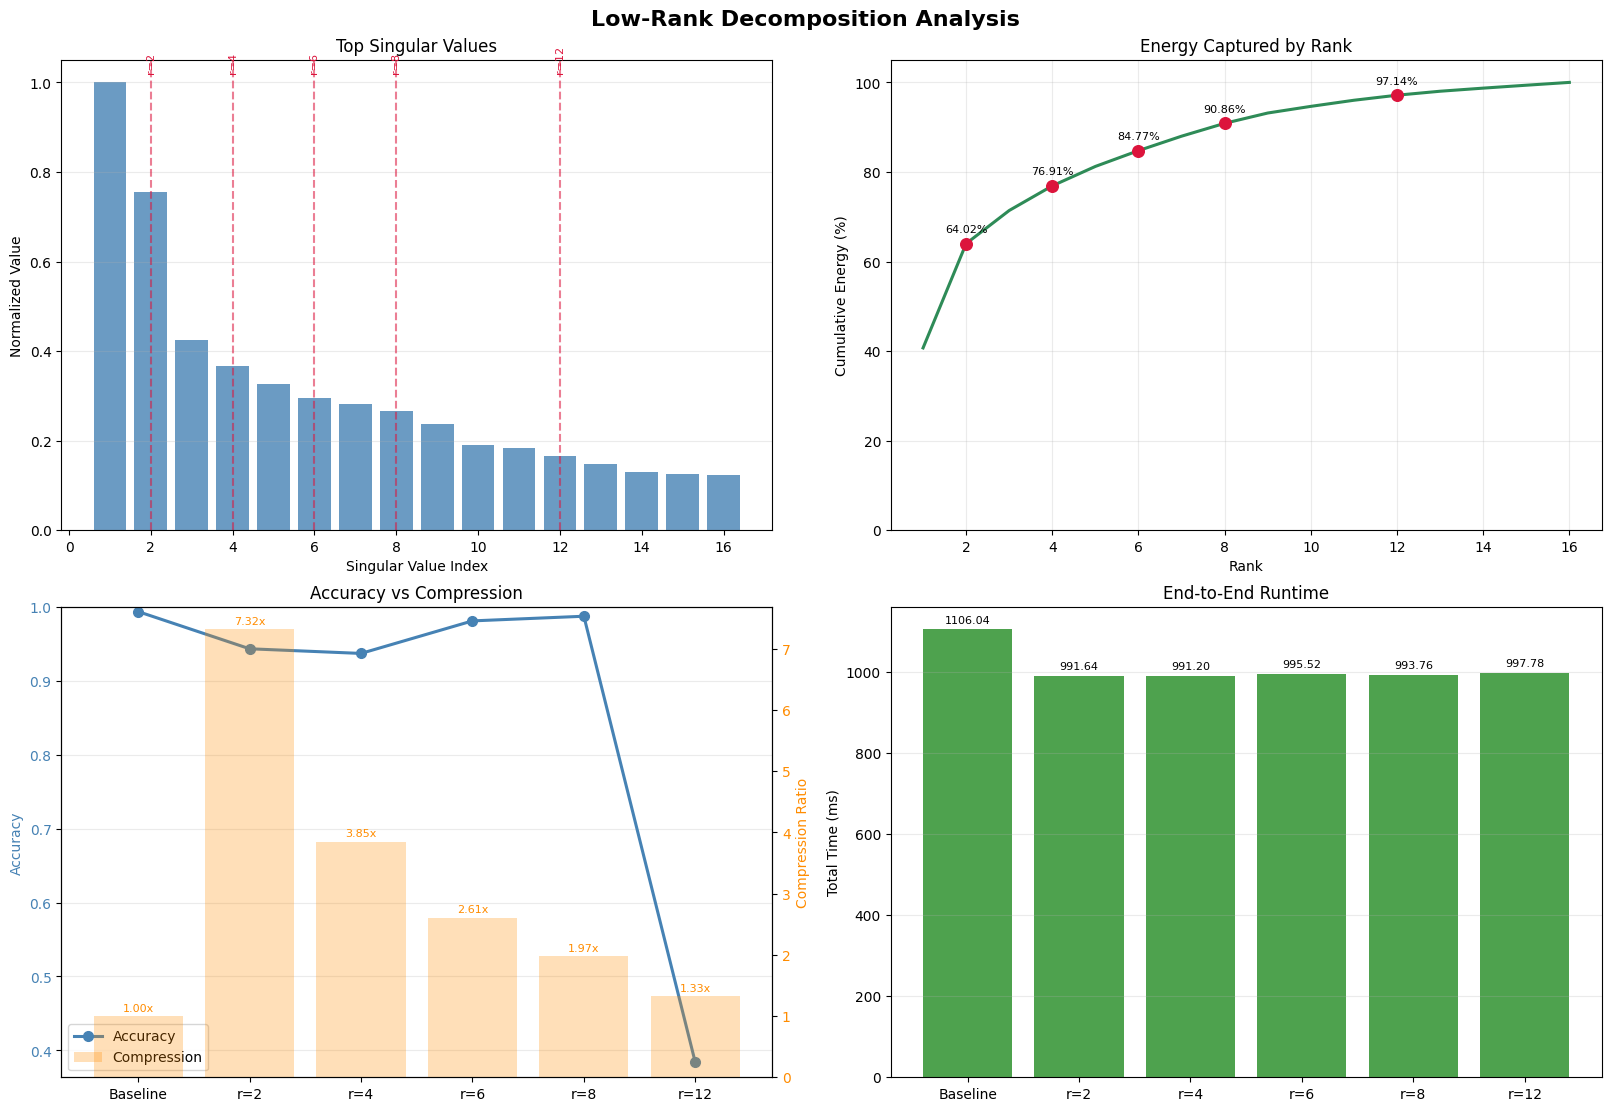

Confusion matrices saved: d:\bintang\skripsi 0606\saved_models_lowrank_20260606_235704\lowrank_confusion_matrices.png


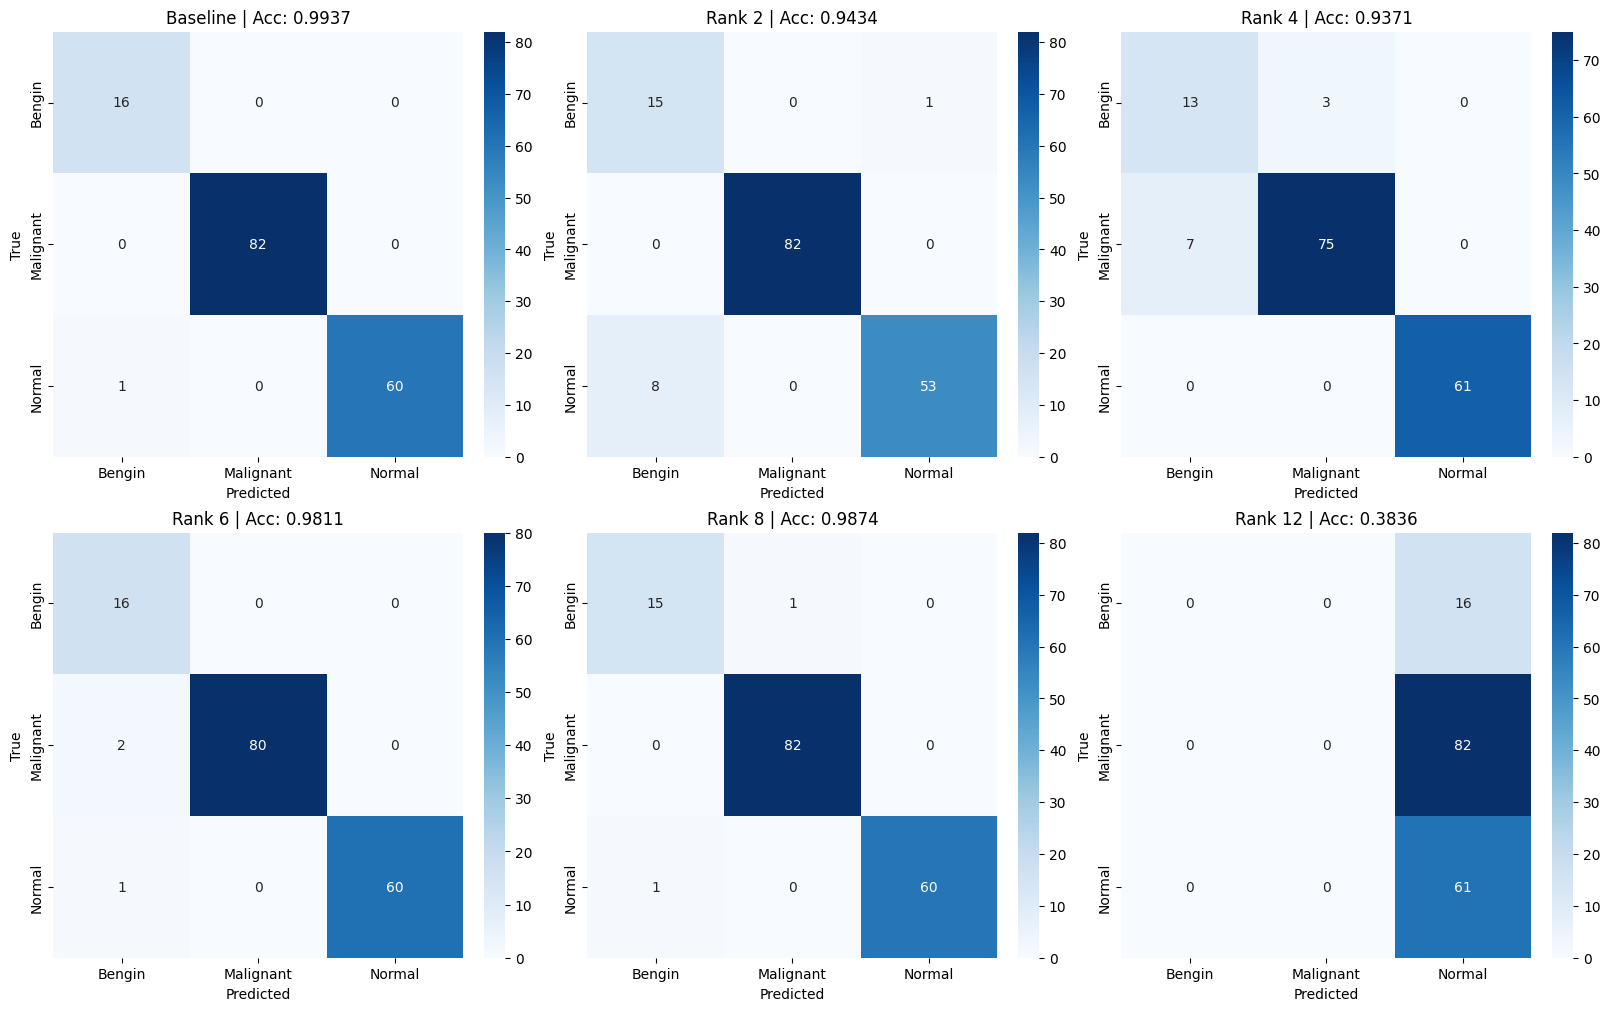

In [15]:
# ============================================================================
# VISUALIZATIONS
# ============================================================================
print("\n" + "="*70)
print("CREATING VISUALIZATIONS")
print("="*70)

sorted_ranks = sorted(ranks_to_test)
labels = ['Baseline'] + [f'r={r}' for r in sorted_ranks]
acc_vals = [metrics_orig['accuracy']] + [results[r]['metrics']['accuracy'] for r in sorted_ranks]
comp_vals = [1.0] + [model_orig.count_params() / results[r]['model'].count_params() for r in sorted_ranks]
feat_times = [metrics_orig['feat_time'] * 1000] + [results[r]['metrics']['feat_time'] * 1000 for r in sorted_ranks]
total_times = [(metrics_orig['feat_time'] + metrics_orig['inf_time']) * 1000] + [(results[r]['metrics']['feat_time'] + results[r]['metrics']['inf_time']) * 1000 for r in sorted_ranks]

fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
fig.suptitle('Low-Rank Decomposition Analysis', fontsize=16, fontweight='bold')

# 1. Singular value spectrum
ax = axes[0, 0]
ax.bar(range(1, min(20, len(S)) + 1), S_norm[:20], color='steelblue', alpha=0.8)
for rank in sorted_ranks:
    ax.axvline(rank, color='crimson', linestyle='--', alpha=0.55)
    ax.text(rank, 1.02, f'r={rank}', rotation=90, va='bottom', ha='center', fontsize=8, color='crimson')
ax.set_xlabel('Singular Value Index')
ax.set_ylabel('Normalized Value')
ax.set_title('Top Singular Values')
ax.grid(alpha=0.25, axis='y')

# 2. Cumulative energy
ax = axes[0, 1]
ax.plot(range(1, len(S) + 1), cum_energy * 100, color='seagreen', linewidth=2.2)
for rank in sorted_ranks:
    energy_at_rank = cum_energy[rank - 1] * 100
    ax.scatter(rank, energy_at_rank, s=70, c='crimson', zorder=5)
    ax.annotate(f'{energy_at_rank:.2f}%', (rank, energy_at_rank), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ax.set_xlabel('Rank')
ax.set_ylabel('Cumulative Energy (%)')
ax.set_title('Energy Captured by Rank')
ax.set_ylim(0, 105)
ax.grid(alpha=0.25)

# 3. Accuracy vs Compression
ax = axes[1, 0]
ax.plot(labels, acc_vals, 'o-', linewidth=2.2, markersize=7, color='steelblue', label='Accuracy')
ax.set_ylabel('Accuracy', color='steelblue')
ax.tick_params(axis='y', labelcolor='steelblue')
ax.set_ylim(max(0, min(acc_vals) - 0.02), 1.0)
ax.grid(alpha=0.25, axis='y')

ax2 = ax.twinx()
ax2.bar(labels, comp_vals, alpha=0.28, color='darkorange', label='Compression')
ax2.set_ylabel('Compression Ratio', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax.set_title('Accuracy vs Compression')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
for i, value in enumerate(comp_vals):
    ax2.text(i, value + 0.05, f'{value:.2f}x', ha='center', va='bottom', fontsize=8, color='darkorange')

# 4. Total time
ax = axes[1, 1]
bars = ax.bar(labels, total_times, color='forestgreen', alpha=0.8)
ax.set_ylabel('Total Time (ms)')
ax.set_title('End-to-End Runtime')
ax.grid(alpha=0.25, axis='y')
for bar, value in zip(bars, total_times):
    ax.text(bar.get_x() + bar.get_width() / 2, value + max(total_times) * 0.01, f'{value:.2f}', ha='center', va='bottom', fontsize=8)

lowrank_analysis_path = os.path.join(out_folder, 'lowrank_analysis.png')
plt.savefig(lowrank_analysis_path, dpi=160, bbox_inches='tight')
print(f"Visualization saved: {lowrank_analysis_path}")
plt.show()
plt.close(fig)

# Confusion matrices
n_models = len(sorted_ranks) + 1
ncols = 3
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

sns.heatmap(metrics_orig['cm'], annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title(f'Baseline | Acc: {metrics_orig["accuracy"]:.4f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

for i, rank in enumerate(sorted_ranks):
    metrics_lr = results[rank]['metrics']
    sns.heatmap(metrics_lr['cm'], annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[i + 1])
    axes[i + 1].set_title(f'Rank {rank} | Acc: {metrics_lr["accuracy"]:.4f}')
    axes[i + 1].set_xlabel('Predicted')
    axes[i + 1].set_ylabel('True')

for j in range(n_models, len(axes)):
    axes[j].axis('off')

lowrank_cm_path = os.path.join(out_folder, 'lowrank_confusion_matrices.png')
plt.savefig(lowrank_cm_path, dpi=160, bbox_inches='tight')
print(f"Confusion matrices saved: {lowrank_cm_path}")
plt.show()
plt.close(fig)

## SAVE RESULTS

In [16]:
# ============================================================================
# FINALIZE LOW-RANK RESULTS
# ============================================================================
print("\n" + "="*70)
print("LOW-RANK COMPRESSION COMPLETE")
print("="*70)

if 'out_folder' not in globals():
    raise RuntimeError("out_folder is not defined. Run the multi-rank low-rank compression cell first.")

df_comp.to_csv(os.path.join(out_folder, "comparison.csv"), index=False)
df_comp.to_json(os.path.join(out_folder, "comparison_table.json"), orient="records", indent=2)
with open(os.path.join(out_folder, "summary.json"), "w") as f:
    json.dump(df_comp.to_dict(orient="records"), f, indent=2)

print(f"\nAll low-rank outputs are in: {out_folder}/")
print("\nSummary:")
for rank in ranks_to_test:
    metrics = results[rank]['metrics']
    comp_ratio = size_baseline / results[rank]['size_kb']
    print(f"\nRank {rank}:")
    print(f"  Compression: {comp_ratio:.2f}x")
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Pipeline size: {results[rank]['size_kb']:.2f} KB")

print("\n" + "="*70)



LOW-RANK COMPRESSION COMPLETE

All low-rank outputs are in: d:\bintang\skripsi 0606\saved_models_lowrank_20260606_235704/

Summary:

Rank 2:
  Compression: 6.68x
  Accuracy: 0.9434
  Pipeline size: 966.20 KB

Rank 4:
  Compression: 3.66x
  Accuracy: 0.9371
  Pipeline size: 1765.22 KB

Rank 6:
  Compression: 2.54x
  Accuracy: 0.9811
  Pipeline size: 2538.61 KB

Rank 8:
  Compression: 1.95x
  Accuracy: 0.9874
  Pipeline size: 3308.49 KB

Rank 12:
  Compression: 1.29x
  Accuracy: 0.3836
  Pipeline size: 4988.96 KB

